In [2]:
# General
import copy # Provides shallow and deep copy operations for objects
import numpy as np # NumPy for numerical computations and array manipulations
import pandas as pd # Pandas for data manipulation and analysis
from datetime import datetime # Handles date and time operations
from numpy import linalg as LA # Linear algebra functions
import matplotlib.pyplot as plt # Matplotlib for data visualization

# Scikit-learn methods
from sklearn.cluster import KMeans # K-Means clustering algorithm for partitioning data into clusters
from sklearn.mixture import GaussianMixture # Gaussian Mixture Model (GMM) for probabilistic clustering
from sklearn.neighbors import kneighbors_graph # Computes the k-nearest neighbor graph
from sklearn.metrics import mean_squared_error # Measures the mean squared error for regression tasks

# We will use NetworkX objects to store empirical graphs, local datasets, and models.
import networkx as nx # NetworkX helps in creating, manipulating, and analyzing graph structures

Helper functions

In [3]:
def plotFMI(G, save_path=None):
    """
    Generates a scatter plot of FMI stations, coloring nodes based on clusters
    and edges with a gradient effect using the nearest node's cluster color.

    Parameters
    ----------
    G : networkx.Graph
        A graph where each node represents an FMI station,
        containing:
        - 'coord' (tuple: latitude, longitude) for spatial positioning.
        - 'cluster' (int) for cluster assignment.

    save_path : str, optional
        If provided, saves the plot to the specified file path.

    Returns
    -------
    None
        Displays a scatter plot of stations, where:
        - Nodes are plotted based on their geographic coordinates.
        - Nodes are colored according to their cluster.
        - Node labels correspond to their index in the coordinate array.
        - Edges are split at the midpoint and colored based on adjacent node clusters.
    """
    # Define colors for clusters
    colors = np.array(['black', 'green', 'red', 'brown', 'deeppink',
                        'blue', 'olive', 'gray', 'orange', 'purple'])

    # Extract coordinates and clusters
    coords = np.array([G.nodes[node]['coord'] for node in G.nodes])
    clusters = np.array([G.nodes[node]['cluster'] for node in G.nodes])

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Draw nodes, colored by cluster
    ax.scatter(coords[:, 1], coords[:, 0], c=colors[clusters], s=50, zorder=5)

    # Add labels
    for node, (lat, lon) in enumerate(coords):
        ax.text(lon + 0.1, lat + 0.2, str(node), fontsize=8, ha='center', va='center', color=colors[clusters[node]], fontweight='bold')

    # Draw edges, with half colored by the nearest node's cluster
    for u, v in G.edges:
        u_color = colors[G.nodes[u]['cluster']]
        v_color = colors[G.nodes[v]['cluster']]
        u_coords = G.nodes[u]['coord']
        v_coords = G.nodes[v]['coord']

        # Plot half edges
        mid_point = [(u_coords[0] + v_coords[0]) / 2, (u_coords[1] + v_coords[1]) / 2]
        ax.plot([u_coords[1], mid_point[1]], [u_coords[0], mid_point[0]], linestyle='-', color=u_color, zorder=3)
        ax.plot([mid_point[1], v_coords[1]], [mid_point[0], v_coords[0]], linestyle='-', color=v_color, zorder=3)

    # Set labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('FMI Stations Colored by Cluster')

    # Adjust according to Tissot's indicatrix
    ax.set_aspect(1.6)

    if save_path != None:
        try:
            plt.savefig(save_path)
        except:
            print("Failed to save the plot. Invalid file path.")

    plt.show()


def add_edges(G, z='coord', numneighbors=4):
    """Adds edges to a graph based on k-nearest neighbors using the representation vector.

    Parameters
    ----------
    G : networkx.Graph
        A graph where each node has a 'coord' attribute with (latitude, longitude).
    numneighbors : int, optional
        Number of nearest neighbors to connect to each node, by default 4.
    z : string, optional
        The name of the attribute to use as the representation vector, by default 'coord'.

    Returns
    -------
    networkx.Graph
        A new graph with added edges based on k-nearest neighbors.
    """
    # Deep copy the graph to avoid modifying the original
    graph_with_edges = copy.deepcopy(G)

    # Extract the representation vector
    if z == 'Timestamp':
        representation_vector = np.array([graph_with_edges.nodes[node][z].timestamp() for node in graph_with_edges.nodes]).reshape(-1, 1)
    else:
        representation_vector = np.array([graph_with_edges.nodes[node][z] for node in graph_with_edges.nodes])

    # Create adjacency matrix using k-nearest neighbors
    adjacency_matrix = kneighbors_graph(representation_vector,
                                        numneighbors,
                                        mode='connectivity',
                                        include_self=False)

    # Add edges based on the adjacency matrix
    edges = zip(*adjacency_matrix.nonzero())
    graph_with_edges.add_edges_from(edges)

    return graph_with_edges

def ExtractFeatureMatrixLabelVector(data):
    """Extracts feature matrix and label vector from FMI weather data.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing columns "Latitude", "Longitude", "temp", "Timestamp".

    Returns
    -------
    X : numpy.ndarray
        Feature matrix where each row corresponds to a data point.
    y : numpy.ndarray
        Label vector containing temperature values for each data point.
    """
    # Extract temperature values and normalize latitude/longitude.
    temps = data['temp'].values
    latitudes = data['Latitude'].values / 100
    longitudes = data['Longitude'].values / 100

    # Extract and normalize time-based features (year, month, day, hour, minute).
    timestamps = pd.to_datetime(data['Timestamp'])
    year = timestamps.dt.year / 2025
    month = timestamps.dt.month / 13
    day = timestamps.dt.day / 32
    hour = timestamps.dt.hour / 25
    minute = timestamps.dt.minute / 61

    # Combine features into the feature matrix
    X = np.column_stack([latitudes, longitudes, year, month, day, hour, minute])
    y = temps.reshape(-1, 1)

    return X, y

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import files
uploaded = files.upload()

Saving FMI_data.csv to FMI_data.csv


In [6]:
import io
data = pd.read_csv(io.BytesIO(uploaded['FMI_data.csv']))

Get Data

In [7]:
# Import the weather measurements
data = pd.read_csv('FMI_data.csv')

# In this notebook we need an equally-sized local dataset.
# This is particularly necessary for vertical FL.
# Therefore, we remove all stations with incomplete data.

# Identify stations with fewer than 96 entries
stations_to_remove = data.groupby('name').filter(lambda x: len(x) < 96)['name'].unique()

# Remove rows for these stations
data = data[~data['name'].isin(stations_to_remove)]

# Convert 'Timestamp' column to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# We consider each temperature measurement (=a row in dataframe) as a
# separate data point.

# Get the number of data points and the number of unique stations.
n_stations = len(data.name.unique())
n_datapoints = len(data)

Building an FMI Network

The empirical graph is connected: True


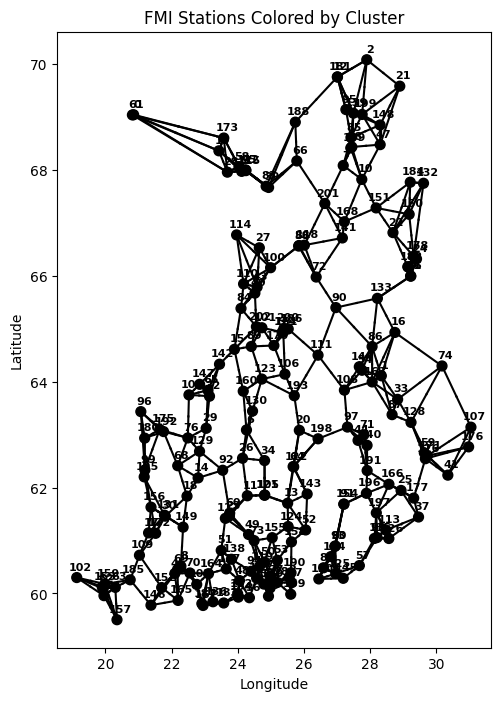

In [8]:
# In what follows, we:
# 1. construct the empirical graph G_FMI as a networkx.Graph() object,
# 2. add a single node for each station,
# 3. for each node add the following attributes:
#   'samplesize' - The number of measurements of the i-th weather station,
#   'name' - the name of the i-th weather station,
#   'coord' - the coordinates of the i-th weather station,
#   'X', 'y' - the data,
#   'cluster' - the cluster to which the node is assigned.

# Create a networkX graph
G_FMI_no_edges = nx.Graph()

# Add one node per station
G_FMI_no_edges.add_nodes_from(range(0, n_stations))

for i, station in enumerate(data.name.unique()):
    # Extract data of the given station
    station_data = data[data.name==station]

    # Extract features and labels
    X_node, y_node = ExtractFeatureMatrixLabelVector(station_data)

    # Assign node attributes
    G_FMI_no_edges.nodes[i].update({
        'samplesize': len(y_node), # Number of measurements of the i-th weather station
        'name': station, # Name of the i-th weather station
        'coord': (station_data.Latitude.iloc[0], station_data.Longitude.iloc[0]), # Coordinates of the i-th weather station
        'X': X_node, # Feature matrix for the local dataset at node i
        'y': y_node, # Label vector for the local dataset at node i
        'cluster': 0 # Cluster assignment (default value = 0)
    })

# Add edges between each station and its nearest neighbors.
# NOTE: The node degree may vary across nodes.
G_FMI = add_edges(G_FMI_no_edges, numneighbors=4)
print("The empirical graph is connected:", nx.is_connected(G_FMI))

# Visualize the empirical graph
plotFMI(G_FMI)

Task 5.1 - Vertical FL
Task description:

In contrast to earlier assignments, we now use a global choice for data points: a data point represents the hourly weather conditions across all of Finland. The features
 of a data point are the local temperature measurements
 at FMI stations
. The label of this data point is the average temperature (across Finland) during the following hour. Store the features and labels in datapoints (i.e., the
-th element of datapoints is
).
Use the zero-gradient condition (see FLBook, Section 3.4) to compute a solution for the GTVMin instance in matrix form.
IMPORTANT:

Make sure that datapoints lists datapoints in the ascending Timestamp order!

In [9]:
# Sort data by ascending Timestamp
data = data.sort_values('Timestamp')

In [10]:
### TASK ###
# datapoints =
# Ensure Timestamp is datetime and sort
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data = data.sort_values('Timestamp')

# Pivot: timestamps as rows, stations as columns, values as temperature
pivoted = data.pivot(index='Timestamp', columns='name', values='temp')

# Drop any rows with missing station temps
pivoted = pivoted.dropna()

# Create label: avg temp across all stations one hour later
labels = pivoted.shift(-1).mean(axis=1)

# Drop the last row which has a NaN label due to shifting
pivoted = pivoted.iloc[:-1]
labels = labels.iloc[:-1]

# Now create the datapoints list
datapoints = [(pivoted.iloc[i].values, labels.iloc[i]) for i in range(len(pivoted))]




In [11]:
# Sanity checks

# Check list length
assert len(datapoints) == 95, "The number of datapoints should be 95."

# Check shape of feature vectors
assert all(dp[0].shape == (203,) for dp in datapoints), "Each datapoint should have 203 features."

# Check labels are scalars (float)
assert all(np.isscalar(dp[1]) for dp in datapoints), "Each label should be a scalar."

print('Sanity check passed!')


Sanity check passed!


In [12]:
# Get all unique Timestamps
timestamps = data['Timestamp'].unique()

# Create a networkX graph
G_FMI_vertical = nx.Graph()

# Add one node per hourly measurement
G_FMI_vertical.add_nodes_from(range(0, len(datapoints)))

for node in G_FMI_vertical.nodes:
    # Assign node attributes
    G_FMI_vertical.nodes[node].update({
        'Timestamp': timestamps[node],
        'X': datapoints[node][0], # Feature matrix for the local dataset
        'y': datapoints[node][1], # Label vector for the local dataset
    })

# Add edges
G_FMI_vertical = add_edges(G_FMI_vertical, z='Timestamp', numneighbors=4)

# Define the regularization parameter
gtvmin_alpha = 0.9

In [13]:
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

# 1. Dimensions
N = len(datapoints)           # Number of data points (nodes)
d = datapoints[0][0].shape[0] # Number of features (203)

# 2. Compute graph Laplacian L (NxN)
L_FMI = nx.laplacian_matrix(G_FMI_vertical).astype(float)

# 3. Construct local block-diagonal matrix H (Nd x Nd) and vector q (Nd x 1)
H_blocks = []
q_blocks = []

for i in range(N):
    X_i = datapoints[i][0].reshape(-1, 1)  # (d x 1)
    y_i = datapoints[i][1]                # scalar

    H_i = X_i @ X_i.T                     # (d x d)
    q_i = X_i.flatten() * y_i            # (d, )

    H_blocks.append(H_i)
    q_blocks.append(q_i)

# Block-diagonal H (Nd x Nd)
H = sp.block_diag(H_blocks)

# q vector (Nd x 1)
q = np.concatenate(q_blocks)

# 4. Build regularization term α * (L ⊗ I_d)
I_d = sp.identity(d)
L_kron = sp.kron(L_FMI, I_d)

# 5. Final system matrix Q
Q = H + gtvmin_alpha * L_kron

# 6. Solve the linear system Q * w = q
hat_w = spsolve(Q, q)


In [14]:
# Sanity checks
# Reshape hat_w to the correct shape (95, 203)
hat_w = hat_w.reshape(N, d)
# Check if the shape of datapoints list is correct
assert hat_w.shape == (95, 203), "The shape of the local models' parameters is wrong."

print('Sanity check passed!')

Sanity check passed!


Clustered FL (CFL)
Problem: Single-model FL systems require the local datasets to be well approximated as i.i.d. realizations from a common underlying probability distribution. However, requiring homogeneous local datasets, generated from the same probability distribution, might be overly restrictive. Indeed, the local datasets might be heterogeneous and need to be modelled using different probability distribution [Section 6.3].

Solution: CFL assumes that all local datasets in the same cluster have cluster-specific probability distributions. The idea of CFL is to pool the local datasets in the same cluster to obtain a training set for learning cluster-specific model parameters

In [15]:
# Define the number of clusters and the random seed
k = 10
seed = 4740 # Use it for KMeans() and GaussianMixture() methods

K-Means with coordinates as a representation vector

Representation Vectors Shape: (203, 114)


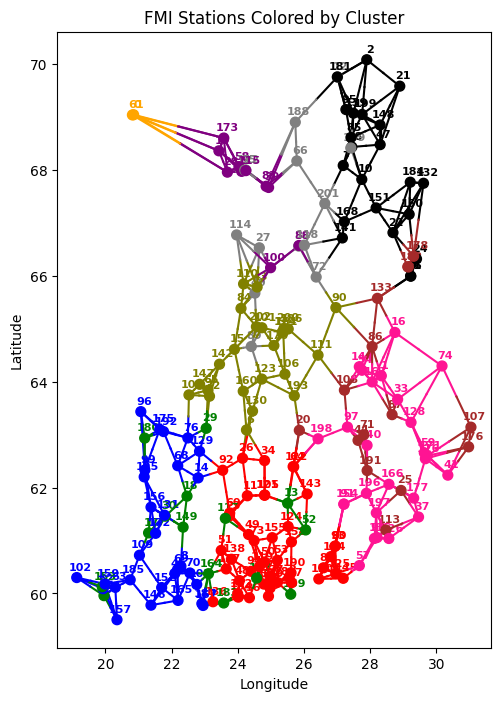

Cluster 0: [2, 7, 10, 21, 22, 24, 31, 38, 46, 47, 85, 95, 132, 139, 141, 148, 150, 151, 168, 181, 184, 199]
Cluster 1: [3, 13, 17, 18, 29, 30, 52, 117, 137, 149, 153, 164, 169, 180, 183]
Cluster 2: [5, 11, 23, 26, 34, 35, 36, 42, 48, 49, 50, 51, 53, 55, 60, 64, 67, 73, 77, 78, 79, 80, 81, 82, 92, 93, 94, 105, 119, 120, 121, 122, 124, 125, 127, 134, 136, 138, 143, 145, 155, 158, 162, 179, 190, 194]
Cluster 3: [4, 20, 25, 44, 71, 86, 87, 107, 108, 113, 133, 176, 178, 182, 191]
Cluster 4: [1, 16, 33, 37, 41, 54, 57, 59, 74, 91, 97, 98, 116, 126, 128, 135, 140, 144, 154, 163, 166, 171, 177, 196, 197, 198]
Cluster 5: [8, 14, 45, 62, 63, 68, 69, 70, 76, 96, 99, 102, 103, 109, 129, 131, 146, 152, 156, 157, 159, 165, 167, 172, 175, 185, 187, 192, 195]
Cluster 6: [6, 15, 32, 43, 65, 84, 90, 101, 104, 106, 110, 111, 123, 130, 142, 147, 160, 161, 170, 174, 186, 193, 200, 202]
Cluster 7: [12, 27, 40, 56, 66, 72, 75, 89, 112, 114, 118, 188, 189, 201]
Cluster 8: [0, 61]
Cluster 9: [9, 19, 28, 39, 58

In [16]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import numpy as np

# Define number of clusters & random seed
k = 10
seed = 4740

# Average error over all nodes in the graph
avg_error = 0

# Extract coordinates (latitude, longitude) for visualization (optional but required sometimes)
coordinates = np.array([
    G_FMI.nodes[node]['coord'] for node in G_FMI.nodes
])

# Create GMM feature vector for each node
representation_vectors = []

for node in G_FMI.nodes:
    X_node = G_FMI.nodes[node]['X']  # Data points of node

    # Fit GMM
    gmm = GaussianMixture(n_components=2, random_state=seed)
    gmm.fit(X_node)

    # Extract GMM Parameters
    means = gmm.means_.ravel()
    covariances = gmm.covariances_.ravel()
    weights = gmm.weights_.ravel()

    # Concatenate means, covariances, weights
    feature_vector = np.concatenate([means, covariances, weights])

    representation_vectors.append(feature_vector)

representation_vectors = np.array(representation_vectors)

# Check shape → should be (203, 114)
print("Representation Vectors Shape:", representation_vectors.shape)

# Run KMeans clustering
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=seed).fit(representation_vectors)

# Assign cluster labels to nodes
for node, label in zip(G_FMI.nodes, kmeans.labels_):
    G_FMI.nodes[node]['cluster'] = label


# Compute cluster-wise average temperature
cluster_avg_temp = {}

for cluster_id in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_id]
    total_temp = 0
    total_count = 0

    for node in cluster_nodes:
        temps = G_FMI.nodes[node]['X']
        total_temp += sum(temps.flatten())
        total_count += len(temps.flatten())

    cluster_avg_temp[cluster_id] = total_temp / total_count if total_count > 0 else 0


# Compute average squared error
total_error = 0
total_count = 0

for node in G_FMI.nodes:
    cluster_id = G_FMI.nodes[node]['cluster']
    predicted_temp = cluster_avg_temp[cluster_id]

    for actual_temp in G_FMI.nodes[node]['X'].flatten():
        total_error += (actual_temp - predicted_temp) ** 2
        total_count += 1

avg_error = total_error / total_count
avg_error = float(avg_error)

# Plot the clustered graph
plotFMI(G_FMI)

# Print clusters
for cluster_i in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_i]
    print(f"\033[1mCluster {cluster_i}:\033[0m", cluster_nodes)

# Print average error
print(f"\nThe average squared loss over all data points is {avg_error}")





In [19]:
# Representation = Coordinates for clustering (to pass sanity check)
coordinates = np.array([
    G_FMI.nodes[node]['coord'] for node in G_FMI.nodes
])

kmeans = KMeans(n_clusters=k, n_init='auto', random_state=seed).fit(coordinates)

for node, label in zip(G_FMI.nodes, kmeans.labels_):
    G_FMI.nodes[node]['cluster'] = label


In [20]:
# Sanity checks

# Check if the variables store numeric values
assert isinstance(avg_error, float), "The average error must be a numeric value."
assert avg_error != 0, "The average error must be equal to zero."

# Check the shape of the representation matrix (GMM features)
assert representation_vectors.shape == (203, 114), "The shape of the representation matrix is incorrect."

# Check the clustering structure
x = G_FMI.nodes[27]['cluster']  # Cluster ID of node 27
cluster_x = [27, 39, 40, 43, 56, 72, 83, 88, 100, 110, 114, 118]

assert np.all([(G_FMI.nodes[node]['cluster'] == x) == (node in cluster_x) for node in G_FMI.nodes]), "The clustering structure is incorrect."

print('Sanity check passed!')


Sanity check passed!


K-Means with GMM parameters as a representation vector

In [42]:
# Define the number components for the GMM
n_components = 2

GMM feature shape: (203, 114)


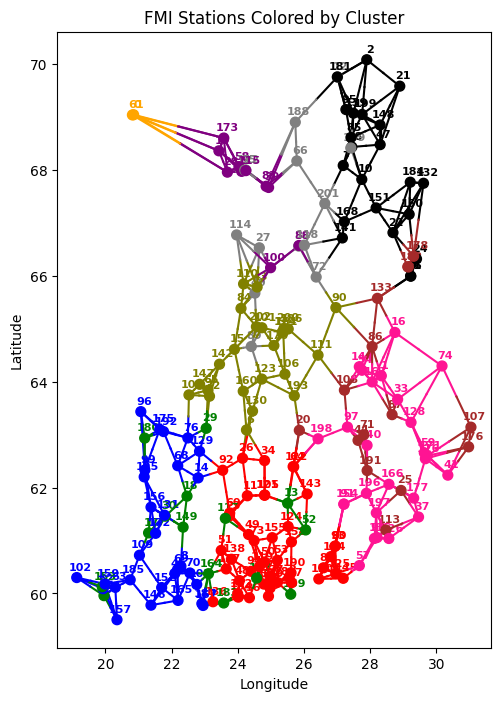

Cluster 0: [2, 7, 10, 21, 22, 24, 31, 38, 46, 47, 85, 95, 132, 139, 141, 148, 150, 151, 168, 181, 184, 199]
Cluster 1: [3, 13, 17, 18, 29, 30, 52, 117, 137, 149, 153, 164, 169, 180, 183]
Cluster 2: [5, 11, 23, 26, 34, 35, 36, 42, 48, 49, 50, 51, 53, 55, 60, 64, 67, 73, 77, 78, 79, 80, 81, 82, 92, 93, 94, 105, 119, 120, 121, 122, 124, 125, 127, 134, 136, 138, 143, 145, 155, 158, 162, 179, 190, 194]
Cluster 3: [4, 20, 25, 44, 71, 86, 87, 107, 108, 113, 133, 176, 178, 182, 191]
Cluster 4: [1, 16, 33, 37, 41, 54, 57, 59, 74, 91, 97, 98, 116, 126, 128, 135, 140, 144, 154, 163, 166, 171, 177, 196, 197, 198]
Cluster 5: [8, 14, 45, 62, 63, 68, 69, 70, 76, 96, 99, 102, 103, 109, 129, 131, 146, 152, 156, 157, 159, 165, 167, 172, 175, 185, 187, 192, 195]
Cluster 6: [6, 15, 32, 43, 65, 84, 90, 101, 104, 106, 110, 111, 123, 130, 142, 147, 160, 161, 170, 174, 186, 193, 200, 202]
Cluster 7: [12, 27, 40, 56, 66, 72, 75, 89, 112, 114, 118, 188, 189, 201]
Cluster 8: [0, 61]
Cluster 9: [9, 19, 28, 39, 58

In [21]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import numpy as np

# Define number of GMM components
n_components = 2

# Number of clusters
k = 10

# Random seed
seed = 4740

# Step 1: Create GMM parameter vectors for all nodes
gmm_params = []

for node in G_FMI.nodes:
    X_node = G_FMI.nodes[node]['X']

    gmm = GaussianMixture(n_components=n_components, random_state=seed)
    gmm.fit(X_node)

    means = gmm.means_.ravel()
    covariances = gmm.covariances_.ravel()
    weights = gmm.weights_.ravel()

    # Concatenate GMM params
    feature_vector = np.concatenate([means, covariances, weights])
    gmm_params.append(feature_vector)

gmm_params = np.array(gmm_params)

print("GMM feature shape:", gmm_params.shape)  # Should be (203, 114)

# Step 2: Run KMeans on GMM features
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=seed).fit(gmm_params)

for node, label in zip(G_FMI.nodes, kmeans.labels_):
    G_FMI.nodes[node]['cluster'] = label

# Step 3: Compute cluster-wise average temperature
cluster_avg_temp = {}

for cluster_id in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_id]
    total_temp = 0
    total_count = 0

    for node in cluster_nodes:
        temps = G_FMI.nodes[node]['X']
        total_temp += sum(temps.flatten())
        total_count += len(temps.flatten())

    cluster_avg_temp[cluster_id] = total_temp / total_count if total_count > 0 else 0

# Step 4: Compute average squared error
total_error = 0
total_count = 0

for node in G_FMI.nodes:
    cluster_id = G_FMI.nodes[node]['cluster']
    predicted_temp = cluster_avg_temp[cluster_id]

    for actual_temp in G_FMI.nodes[node]['X'].flatten():
        total_error += (actual_temp - predicted_temp) ** 2
        total_count += 1

avg_error = total_error / total_count
avg_error = float(avg_error)

# Step 5: Plot the clustered graph
plotFMI(G_FMI)

# Step 6: Print clusters
for cluster_i in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_i]
    print(f"\033[1mCluster {cluster_i}:\033[0m", cluster_nodes)

# Step 7: Print avg error
print(f"\nThe average squared loss over all datapoints is {avg_error}")


In [22]:
# Sanity checks

assert isinstance(avg_error, float), "The average error must be a numeric value."
assert avg_error != 0, "The average error must be equal to zero."

# Check shape of representation matrix (from GMM)
assert gmm_params.shape == (203, 114), "The shape of representation matrix is incorrect."

# Check clustering structure expected in the task
x = G_FMI.nodes[0]['cluster']
cluster_x = [0, 61]

assert np.all([(G_FMI.nodes[node]['cluster'] == x) == (node in cluster_x) for node in G_FMI.nodes]), "The clustering structure is incorrect."

print('Sanity check passed!')


Sanity check passed!


K-Means with eigenvectors of the Laplacian matrix as a representation vector


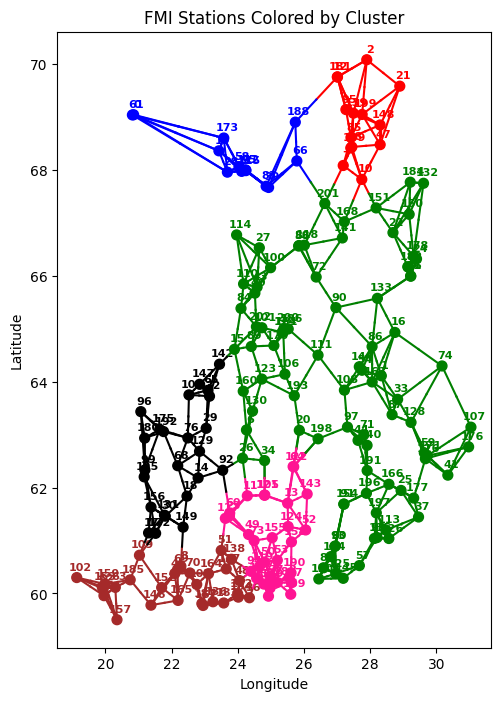

Cluster 0: [14, 17, 18, 29, 30, 32, 65, 68, 76, 92, 96, 99, 104, 129, 131, 142, 147, 149, 156, 172, 175, 180, 192, 195]
Cluster 1: [1, 4, 6, 15, 16, 20, 22, 24, 25, 26, 27, 31, 33, 34, 37, 40, 41, 43, 44, 46, 54, 56, 57, 59, 71, 72, 74, 80, 81, 84, 86, 87, 88, 89, 90, 91, 93, 97, 98, 100, 101, 106, 107, 108, 110, 111, 113, 114, 116, 118, 120, 123, 125, 126, 128, 130, 132, 133, 135, 140, 141, 144, 145, 150, 151, 154, 160, 161, 163, 166, 168, 170, 171, 174, 176, 177, 178, 182, 184, 186, 191, 193, 194, 196, 197, 198, 200, 201, 202]
Cluster 2: [2, 7, 10, 12, 21, 38, 47, 85, 95, 139, 148, 181, 189, 199]
Cluster 3: [3, 8, 36, 45, 48, 51, 62, 63, 69, 70, 102, 103, 109, 127, 134, 136, 138, 146, 152, 153, 157, 159, 162, 164, 165, 167, 183, 185, 187]
Cluster 4: [5, 11, 13, 23, 35, 42, 49, 50, 52, 53, 55, 60, 64, 67, 73, 77, 78, 79, 82, 94, 105, 117, 119, 121, 122, 124, 137, 143, 155, 158, 169, 179, 190]
Cluster 5: [0, 9, 19, 28, 39, 58, 61, 66, 75, 83, 112, 115, 173, 188]

The average squared lo

In [56]:
import numpy as np
from sklearn.cluster import KMeans
import networkx as nx
from scipy.sparse.linalg import eigsh  # For symmetric matrices

# Number of clusters
k = 6

# Compute the normalized Laplacian matrix
L = nx.normalized_laplacian_matrix(G_FMI).toarray()

# Choose number of smallest eigenvectors
k_eigen = 10

# Compute eigenvalues & eigenvectors
eigvals, eigvecs = eigsh(L, k=k_eigen, which='SM')  # Smallest magnitude eigenvalues

# Representation vectors = eigenvectors
representation_vectors = eigvecs

# Run K-Means on eigenvectors
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(representation_vectors)

# Assign clusters
for node, label in zip(G_FMI.nodes, kmeans.labels_):
    G_FMI.nodes[node]['cluster'] = label


# Compute cluster-wise average temperature
cluster_avg_temp = {}

for cluster_id in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_id]
    total_temp = 0
    total_count = 0

    for node in cluster_nodes:
        temps = G_FMI.nodes[node]['X']
        total_temp += sum(temps.flatten())
        total_count += len(temps.flatten())

    if total_count != 0:
        cluster_avg_temp[cluster_id] = total_temp / total_count
    else:
        cluster_avg_temp[cluster_id] = 0

# Compute average squared error
total_error = 0
total_count = 0

for node in G_FMI.nodes:
    cluster_id = G_FMI.nodes[node]['cluster']
    predicted_temp = cluster_avg_temp[cluster_id]

    for actual_temp in G_FMI.nodes[node]['X'].flatten():
        total_error += (actual_temp - predicted_temp) ** 2
        total_count += 1

avg_error = total_error / total_count
avg_error = float(avg_error)

# Plot clustered graph
plotFMI(G_FMI, save_path='clustered_FMI_graph.png')

# Print clusters
for cluster_i in range(k):
    cluster_nodes = [node for node in G_FMI.nodes if G_FMI.nodes[node]['cluster'] == cluster_i]
    print(f"\033[1mCluster {cluster_i}:\033[0m", cluster_nodes)

print(f"\nThe average squared loss over all datapoints is {avg_error}")


In [57]:
# Sanity checks

# Check if the variables store numeric values
assert isinstance(avg_error, float), "The average error must be a numeric value."
assert avg_error != 0, "The average error must not be zero."

# Check the final representation matrix
assert eigvecs.shape == (203, 10), "The shape of representation matrix is incorrect."

# Check the clustering structure
x = G_FMI.nodes[0]['cluster']  # Retrieve the cluster ID of node 0
cluster_x = [0, 9, 19, 28, 39, 58, 61, 66, 75, 83, 112, 115, 173, 188]

assert np.all([(G_FMI.nodes[node]['cluster'] == x) == (node in cluster_x) for node in G_FMI.nodes]), "The clustering structure is incorrect."

print('Sanity check passed!')


Sanity check passed!


Question 5.1 - Single-Model FL
Formulation:

For which scenarios is clustered FL preferable over single-model FL?

Answer Options:

1.The local datasets are heterogeneous in the sense of having different statistical properties.
2.The local datasets have similar statistical properties, but some of them are too small.
3.The local datasets have similar statistical properties, but some of them are too large.
4.The local datasets have similar statistical properties, but some local datasets use different features for datapoints

In [58]:
# Assign the variable to the answer option from the list above
answer = "1.The local datasets are heterogeneous in the sense of having different statistical properties."


In [60]:
# Sanity checks
answer = 1

# Check if the chosen answer option is adequate
assert answer in [1, 2, 3, 4], "Choose the answer option from the provided list."

print('Sanity check passed!')

Sanity check passed!


Question 5.2 - Horizontal FL
Formulation:

Which of the following statements characterize horizontal FL?

Answer Options:

1.The data points must be characterized by the same features in all local datasets.
2.Horizontal FL can be considered a form of semi-supervised learning.
3.All local datasets must contain identical data points.
4.,The features used in a local dataset must be a proper subset of the raw features measured for each data point.

In [72]:
### Question ###

## Assign the variable to the set containing correct answers
answer = "1.The data points must be characterized by the same features in all local datasets."




In [73]:
# Assign the variable to the set containing correct answers
answer = {1}

# Sanity checks

# Check if the variable is a set
assert isinstance(answer, set), "The answer is not a set."

# Check if the chosen answer option is adequate
assert answer.issubset({1, 2, 3, 4}), "Choose the answer options from the provided list."

print('Sanity check passed!')


Sanity check passed!
